# Robust Descriptives, Concentration & Rank Correlation

Replaces mean ± SD summaries and the Pearson heatmap with quantile-based summaries, concentration measures (Lorenz curve, Gini, top-*k* share), log-scale distribution plots and Spearman correlations with Holm-adjusted p-values.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sys.path.append(str(Path.cwd().parent))  # project root: import via the src package so src/statistics.py cannot shadow the stdlib module
from src import statistics as rs

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12})
pd.options.display.float_format = "{:,.4g}".format
pd.options.display.width = 140

df = rs.load_robust()
CLS = rs.CLASS_ORDER
PAL = rs.CLASS_COLORS
print(f"n = {len(df):,}  |  columns = {df.shape[1]}")

n = 1,500  |  columns = 20


## 1. Robust summary statistics

In [2]:
vars_ = {
    "revenue": df.revenue, "copiesSold": df.copiesSold.astype(float), "price (paid)": df.price.where(df.price > 0),
    "avgPlaytime": df.avgPlaytime.where(df.avgPlaytime > 0), "reviewScore (scored)": df.reviewScore_clean,
}

def robust_summary(s):
    s = s.dropna()
    q = s.quantile([.05, .25, .5, .75, .95])
    return pd.Series({
        "n": len(s), "median": q[.5], "IQR": q[.75] - q[.25], "MAD": stats.median_abs_deviation(s, scale="normal"),
        "P05": q[.05], "P95": q[.95], "10% trimmed mean": stats.trim_mean(s, .10),
        "mean": s.mean(), "geo. mean": rs.geometric_mean(s) if (s > 0).all() else np.nan,
        "mean / median": s.mean() / q[.5],
    })

summary = pd.DataFrame({k: robust_summary(v) for k, v in vars_.items()}).T
rs.save_table(summary.reset_index().rename(columns={"index": "variable"}), "robust_summary_statistics.csv")
summary

,n,median,IQR,MAD,P05,P95,10% trimmed mean,mean,geo. mean,mean / median
revenue,"1,500",1.091e+05,4.097e+05,1.19e+05,2.387e+04,4.557e+06,2.788e+05,2.632e+06,1.717e+05,24.14
copiesSold,"1,500",1.193e+04,3.295e+04,1.324e+04,"1,864",3.062e+05,2.262e+04,1.415e+05,1.543e+04,11.86
price (paid),"1,415",14.99,15,7.413,4.99,39.99,16.77,18.57,15.25,1.239
avgPlaytime,"1,499",6.763,9.536,5.916,1.465,39.91,8.558,12.57,7.098,1.859
reviewScore (scored),"1,401",85,17,11.86,53,98,83.43,81.59,80.06,0.9598


`mean / median` quantifies how far the arithmetic mean has been pulled by the tail: for revenue the mean is ~24× the median, so "the average game earns $2.6M" describes almost no actual game.

## 2. Revenue concentration

In [3]:
x = df.revenue.values
tops = pd.DataFrame({
    "share of total revenue": [rs.top_share(x, k=1), rs.top_share(x, k=10), rs.top_share(x, k=15),
                               rs.top_share(x, frac=.01), rs.top_share(x, frac=.05), rs.top_share(x, frac=.10),
                               rs.top_share(x, frac=.20)],
}, index=["Top 1 game", "Top 10 games", "Top 15 games", "Top 1% (15 games)", "Top 5% (75)", "Top 10% (150)", "Top 20% (300)"])
tops["share of total revenue"] = (tops["share of total revenue"] * 100).round(1).astype(str) + " %"
print(f"Gini coefficient (revenue): {rs.gini(x):.3f}")
print(f"Gini coefficient (copies) : {rs.gini(df.copiesSold):.3f}")
tops

Gini coefficient (revenue): 0.935
Gini coefficient (copies) : 0.901


,share of total revenue
Top 1 game,21.2 %
Top 10 games,61.6 %
Top 15 games,67.8 %
Top 1% (15 games),67.8 %
Top 5% (75),86.0 %
Top 10% (150),91.4 %
Top 20% (300),95.8 %


In [4]:
by_class = df.groupby("publisherClass").agg(
    n_games=("revenue", "size"), total_revenue=("revenue", "sum"), median_revenue=("revenue", "median"),
    q1=("revenue", lambda s: s.quantile(.25)), q3=("revenue", lambda s: s.quantile(.75)),
).loc[CLS]
by_class["% of games"] = 100 * by_class.n_games / by_class.n_games.sum()
by_class["% of revenue"] = 100 * by_class.total_revenue / by_class.total_revenue.sum()
by_class["gini"] = [rs.gini(df.loc[df.publisherClass == c, "revenue"]) for c in CLS]
rs.save_table(by_class.reset_index(), "robust_revenue_by_class.csv")
by_class.round(3)

,n_games,total_revenue,median_revenue,q1,q3,% of games,% of revenue,gini
publisherClass,,,,,,,,
Indie,1302,8.771e+08,9.077e+04,4.22e+04,3.11e+05,86.8,22.21,0.826
AA,146,1.485e+09,6.722e+05,1.474e+05,2.238e+06,9.733,37.61,0.894
AAA,52,1.587e+09,9.289e+05,2.66e+05,3.253e+06,3.467,40.18,0.928


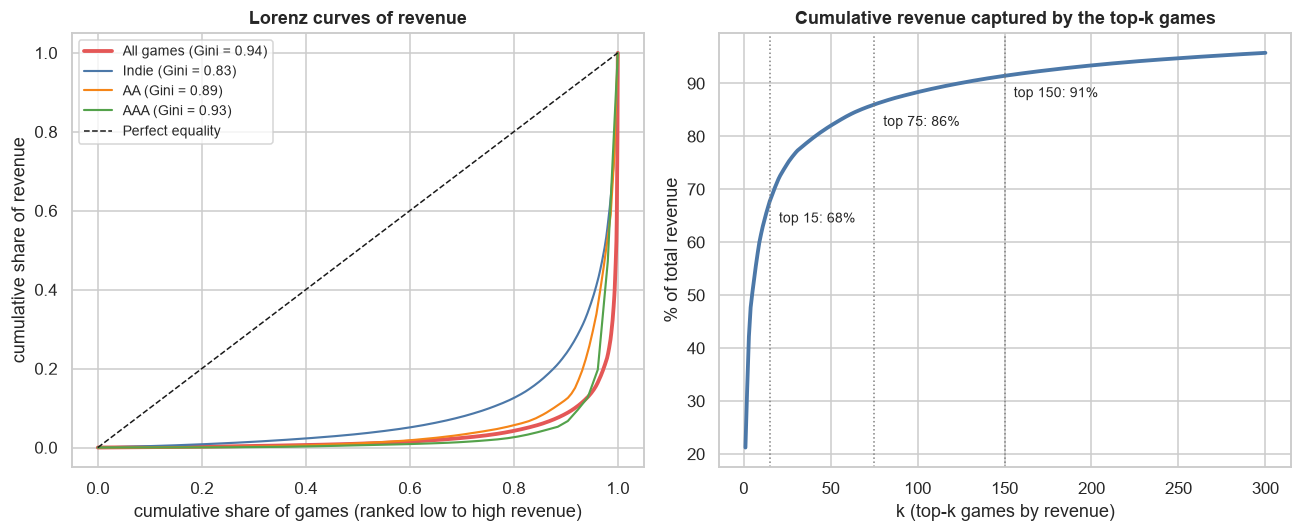

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
p, l = rs.lorenz_curve(x)
axes[0].plot(p, l, lw=2.5, color="#E45756", label=f"All games (Gini = {rs.gini(x):.2f})")
for c in CLS:
    pc, lc = rs.lorenz_curve(df.loc[df.publisherClass == c, "revenue"])
    axes[0].plot(pc, lc, lw=1.4, color=PAL[c], label=f"{c} (Gini = {rs.gini(df.loc[df.publisherClass == c, 'revenue']):.2f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Perfect equality")
axes[0].set_xlabel("cumulative share of games (ranked low to high revenue)"); axes[0].set_ylabel("cumulative share of revenue")
axes[0].set_title("Lorenz curves of revenue"); axes[0].legend(loc="upper left", fontsize=9)

ks = np.arange(1, 301)
srt = np.sort(x)[::-1]
axes[1].plot(ks, np.cumsum(srt)[:300] / x.sum() * 100, color="#4C78A8", lw=2.5)
for k in (15, 75, 150):
    axes[1].axvline(k, color="grey", ls=":", lw=1)
    axes[1].annotate(f"top {k}: {srt[:k].sum() / x.sum():.0%}", (k, srt[:k].sum() / x.sum() * 100), textcoords="offset points",
                     xytext=(6, -14), fontsize=9)
axes[1].set_xlabel("k (top-k games by revenue)"); axes[1].set_ylabel("% of total revenue")
axes[1].set_title("Cumulative revenue captured by the top-k games")
fig.tight_layout(); rs.save_fig(fig, "r02_lorenz_concentration.png"); plt.show()

## 3. Distributions on the log scale, by publisher class

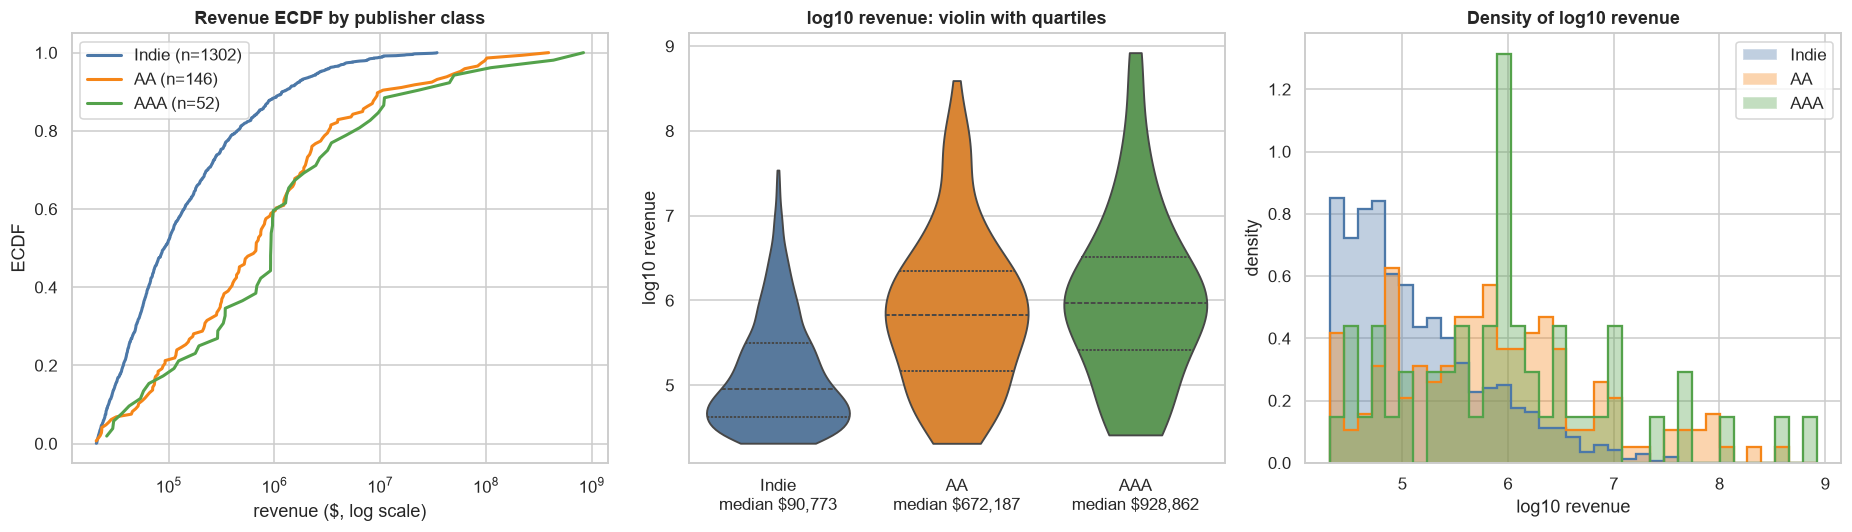

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) ECDF on log-x
for c in CLS:
    v = np.sort(df.loc[df.publisherClass == c, "revenue"])
    axes[0].plot(v, np.arange(1, len(v) + 1) / len(v), color=PAL[c], lw=2, label=f"{c} (n={len(v)})")
axes[0].set_xscale("log"); axes[0].set_xlabel("revenue ($, log scale)"); axes[0].set_ylabel("ECDF")
axes[0].set_title("Revenue ECDF by publisher class"); axes[0].legend()

# (b) violin + strip on log10 revenue
sns.violinplot(data=df, x="publisherClass", y="log_revenue", order=CLS, palette=PAL, inner="quartile", cut=0, ax=axes[1])
axes[1].set_ylabel("log10 revenue"); axes[1].set_xlabel("")
axes[1].set_title("log10 revenue: violin with quartiles")
med = df.groupby("publisherClass")["revenue"].median().loc[CLS]
axes[1].set_xticklabels([f"{c}\nmedian ${med[c]:,.0f}" for c in CLS])

# (c) density of log10 revenue (uniform bins in log space => heights are comparable)
bins = np.linspace(df.log_revenue.min(), df.log_revenue.max(), 36)
for c in CLS:
    v = df.loc[df.publisherClass == c, "log_revenue"]
    axes[2].hist(v, bins=bins, density=True, histtype="stepfilled", alpha=.35, color=PAL[c], label=c)
    axes[2].hist(v, bins=bins, density=True, histtype="step", color=PAL[c], lw=1.5)
axes[2].set_xlabel("log10 revenue"); axes[2].set_ylabel("density")
axes[2].set_title("Density of log10 revenue"); axes[2].legend()
fig.tight_layout(); rs.save_fig(fig, "r02_revenue_by_class_logscale.png"); plt.show()

## 4. Spearman correlation matrix (Holm-adjusted)

Spearman ρ is invariant to monotone transforms, so it already "sees" the log scale and is not driven by the extreme tail as Pearson r is. All 10 pairwise p-values are Holm-adjusted as one family.

In [7]:
import pingouin as pg

cols = ["revenue", "copiesSold", "price", "avgPlaytime", "reviewScore_clean"]
labels = {"revenue": "revenue", "copiesSold": "copies", "price": "price", "avgPlaytime": "playtime", "reviewScore_clean": "review"}
sub = df[cols].astype(float).rename(columns=labels)
pc = pg.pairwise_corr(sub, method="spearman", padjust="holm")[["X", "Y", "n", "r", "CI95", "p_unc", "p_corr"]]
pc = pc.rename(columns={"r": "spearman_rho", "p_unc": "p_raw", "p_corr": "p_holm", "CI95": "CI95%"})
rs.save_table(pc, "robust_spearman_pairs.csv")
pc

ModuleNotFoundError: No module named 'pingouin'

In [ ]:
rho = sub.corr(method="spearman")
padj = pd.DataFrame(np.nan, index=rho.index, columns=rho.columns)
for _, r_ in pc.iterrows():
    padj.loc[r_.X, r_.Y] = padj.loc[r_.Y, r_.X] = r_.p_holm

annot = rho.round(2).astype(str)
for i in rho.index:
    for j in rho.columns:
        if i != j and padj.loc[i, j] >= .05:
            annot.loc[i, j] += "\n(n.s.)"

fig, ax = plt.subplots(figsize=(7.5, 6))
mask = np.triu(np.ones_like(rho, dtype=bool), k=1)
sns.heatmap(rho, mask=mask, annot=annot, fmt="", cmap="RdBu_r", vmin=-1, vmax=1, square=True, linewidths=.5,
            cbar_kws={"label": "Spearman rho"}, ax=ax)
ax.set_title("Spearman correlations (n.s. = Holm-adjusted p >= .05)")
fig.tight_layout(); rs.save_fig(fig, "r02_spearman_heatmap.png"); plt.show()

### 4.1 Review score vs revenue: controlling for confounders and within class

The Week 2 finding was a weak marginal correlation. Two checks: a *partial* Spearman correlation controlling for price and playtime, and the correlation *within* each publisher class (a Simpson's-paradox check).

In [ ]:
d2 = df[["reviewScore_clean", "revenue", "price", "avgPlaytime", "publisherClass"]].dropna()
d2 = d2[d2.avgPlaytime > 0]
partial = pg.partial_corr(d2, x="reviewScore_clean", y="revenue", covar=["price", "avgPlaytime"], method="spearman")
print("Partial Spearman, review vs revenue | price, playtime")
print(partial[["n", "r", "CI95", "p_val"]].round(4).to_string())

rows = []
for c in CLS:
    g = d2[d2.publisherClass == c]
    r_, p_ = stats.spearmanr(g.reviewScore_clean, g.revenue)
    rows.append([c, len(g), r_, p_])
within = pd.DataFrame(rows, columns=["class", "n", "spearman_rho", "p_raw"])
within["p_holm"] = pg.multicomp(within.p_raw.values, method="holm")[1]
print("\nWithin-class Spearman, review vs revenue")
print(within.round(4).to_string(index=False))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
g = df.dropna(subset=["reviewScore_clean"])
hb = axes[0].hexbin(g.reviewScore_clean, g.revenue, yscale="log", gridsize=32, cmap="viridis", mincnt=1, bins="log")
bins_ = pd.cut(g.reviewScore_clean, [0, 60, 70, 80, 90, 100])
m = g.groupby(bins_)["revenue"].median()
mid = [30, 65, 75, 85, 95]
axes[0].plot(mid, m.values, "o-", color="#E45756", lw=2, label="median revenue per score band")
axes[0].set_xlabel("review score"); axes[0].set_ylabel("revenue ($, log)"); axes[0].set_title("Review score vs revenue"); axes[0].legend(loc="upper left")
fig.colorbar(hb, ax=axes[0], label="games (log)")

p_ = df[~df.is_free]
hb = axes[1].hexbin(p_.price, p_.copiesSold, xscale="log", yscale="log", gridsize=32, cmap="viridis", mincnt=1, bins="log")
axes[1].set_xlabel("price ($, log)"); axes[1].set_ylabel("copies sold (log)"); axes[1].set_title("Price vs copies sold (paid games)")
fig.colorbar(hb, ax=axes[1], label="games (log)")

q = df[df.avgPlaytime > 0]
hb = axes[2].hexbin(q.avgPlaytime, q.revenue, xscale="log", yscale="log", gridsize=32, cmap="viridis", mincnt=1, bins="log")
axes[2].set_xlabel("avg playtime (log)"); axes[2].set_ylabel("revenue ($, log)"); axes[2].set_title("Playtime vs revenue")
fig.colorbar(hb, ax=axes[2], label="games (log)")
fig.tight_layout(); rs.save_fig(fig, "r02_hexbin_relationships.png"); plt.show()

---

## From correlation to regression

The correlations above describe pairwise relationships. The section below models revenue directly, holding the other factors fixed.

## Regression Models for Revenue

Pairwise tests answer "do groups differ?". They cannot say *which factors matter once the others are held fixed*. This notebook models revenue directly with three complementary, heavy-tail-appropriate specifications:

1. **OLS on log10 revenue** with heteroscedasticity-robust (HC3) standard errors — the primary model; coefficients read as *multiplicative* effects on revenue.
2. **Quantile regression** (10th → 90th percentile) — do drivers act differently for flops vs. hits?
3. **Gamma GLM (log link) on raw revenue** — a mean-scale cross-check that needs no back-transformation.

**Design decisions**

* `copiesSold` and `revenue_per_copy` are **excluded**: revenue is (roughly) price × copies, so including them would recover an accounting identity, not a driver (notebook 01).
* Free-to-play games get an indicator `free`; `log_price_c` is the centred log price of paid games (0 for free games).
* Primary model uses the 1,400 games with a review score and non-zero playtime; the 99 unscored games are added back in a sensitivity model with a missing-indicator.
* **Caveat.** The sample is the top 1,500 by revenue, i.e. *truncated on the outcome*. Coefficients describe associations among already-successful games and are attenuated relative to the full Steam catalogue.

In [ ]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sys.path.append(str(Path.cwd().parent))  # project root: import via the src package so src/statistics.py cannot shadow the stdlib module
from src import statistics as rs

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12})
pd.options.display.float_format = "{:,.4g}".format
pd.options.display.width = 140

df = rs.load_robust()
CLS = rs.CLASS_ORDER
PAL = rs.CLASS_COLORS
print(f"n = {len(df):,}  |  columns = {df.shape[1]}")

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

m = df.dropna(subset=["reviewScore_clean", "log_playtime"]).copy()
paid_mean = m.loc[~m.is_free, "log_price"].mean()
m["free"] = m.is_free.astype(int)
m["log_price_c"] = m.log_price.fillna(paid_mean) - paid_mean
m["review10"] = (m.reviewScore_clean - 85) / 10           # per 10 points, centred at the median score
m["log_playtime_c"] = m.log_playtime - m.log_playtime.mean()
m["cls"] = pd.Categorical(m.publisherClass.astype(str), CLS)

RHS = "C(cls, Treatment('Indie')) + free + log_price_c + review10 + log_playtime_c"
NAMES = {"C(cls, Treatment('Indie'))[T.AA]": "AA (vs Indie)", "C(cls, Treatment('Indie'))[T.AAA]": "AAA (vs Indie)",
         "free": "free-to-play", "log_price_c": "price (x10, paid games)", "review10": "review score (+10 pts)",
         "log_playtime_c": "playtime (x10)", "Intercept": "Intercept (Indie, paid, median price/score/playtime)"}
print(f"Modelling sample: n = {len(m):,} of {len(df):,}")

## 1. OLS on log10 revenue with HC3 standard errors

In [ ]:
ols_c = smf.ols("log_revenue ~ " + RHS, m).fit()                    # classical SEs, for diagnostics
ols = smf.ols("log_revenue ~ " + RHS, m).fit(cov_type="HC3")        # reported model

ci = ols.conf_int()
coef = pd.DataFrame({
    "coef (log10)": ols.params, "SE (classical)": ols_c.bse, "SE (HC3)": ols.bse,
    "multiplier on revenue": 10 ** ols.params, "mult. CI low": 10 ** ci[0], "mult. CI high": 10 ** ci[1], "p (HC3)": ols.pvalues,
}).rename(index=NAMES)
coef.loc["Intercept (Indie, paid, median price/score/playtime)", ["multiplier on revenue", "mult. CI low", "mult. CI high"]] = \
    (10 ** ols.params["Intercept"], 10 ** ci.loc["Intercept", 0], 10 ** ci.loc["Intercept", 1])
print(f"R2 = {ols.rsquared:.3f}  |  adj. R2 = {ols.rsquared_adj:.3f}  |  n = {int(ols.nobs):,}")
print("Multiplier = factor by which median-type (geometric-mean) revenue changes; e.g. 2.0 = doubles.")
rs.save_table(coef.reset_index().rename(columns={"index": "term"}), "regression_ols_log_revenue.csv")
coef

### 1.1 Which block of predictors matters most? (drop-one ΔR²)

In [ ]:
blocks = {"publisher class": "C(cls, Treatment('Indie'))", "free-to-play": "free", "price": "log_price_c",
          "review score": "review10", "playtime": "log_playtime_c"}
full_r2 = ols_c.rsquared
rows = []
for name, term in blocks.items():
    rhs = " + ".join(t for k, t in blocks.items() if k != name)
    rows.append([name, full_r2 - smf.ols("log_revenue ~ " + rhs, m).fit().rsquared])
dr2 = pd.DataFrame(rows, columns=["dropped block", "delta R2"]).sort_values("delta R2", ascending=False)
dr2["% of full R2"] = 100 * dr2["delta R2"] / full_r2
dr2

## 2. Diagnostics: are the model's assumptions credible on the log scale?

In [ ]:
resid, fitted = ols_c.resid, ols_c.fittedvalues
infl = ols_c.get_influence()
cooks = infl.cooks_distance[0]
thr = 4 / len(m)

X = ols_c.model.exog
vif = pd.Series([variance_inflation_factor(X, i) for i in range(1, X.shape[1])], index=[NAMES.get(n, n) for n in ols_c.model.exog_names[1:]], name="VIF")
bp = het_breuschpagan(resid, X)
print(f"Residual skew = {stats.skew(resid):.2f}, excess kurtosis = {stats.kurtosis(resid):.2f}")
print(f"Breusch-Pagan heteroscedasticity: LM = {bp[0]:.2f}, p = {bp[1]:.3g}  ->  HC3 SEs used for inference")
print(f"Observations with Cook's D > 4/n: {(cooks > thr).sum()} ({(cooks > thr).mean():.1%}); max Cook's D = {cooks.max():.3f}")
print("\nVariance inflation factors (all < 5 = no material collinearity):")
print(vif.round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
sm.qqplot(resid, line="s", ax=axes[0], markersize=3, alpha=.6); axes[0].set_title("Residual Q-Q plot")
axes[1].scatter(fitted, resid, s=8, alpha=.4); axes[1].axhline(0, color="k", lw=1)
lo = sm.nonparametric.lowess(resid, fitted, frac=.3); axes[1].plot(lo[:, 0], lo[:, 1], color="#E45756", lw=2)
axes[1].set_xlabel("fitted log10 revenue"); axes[1].set_ylabel("residual"); axes[1].set_title("Residuals vs fitted (red = LOWESS)")
axes[2].stem(np.arange(len(cooks)), cooks, markerfmt=" ", basefmt=" ", linefmt="C0-")
axes[2].axhline(thr, color="#E45756", ls="--", label="4/n"); axes[2].set_xlabel("observation"); axes[2].set_ylabel("Cook's D")
axes[2].set_title("Influence"); axes[2].legend()
fig.tight_layout(); rs.save_fig(fig, "r02_ols_diagnostics.png"); plt.show()

## 3. Sensitivity of the OLS coefficients

Three refits: (a) drop high-influence points (Cook's D > 4/n); (b) add the 99 unscored games back with a missing-review indicator; (c) add release-month fixed effects (seasonality).

In [ ]:
keep = m.loc[cooks <= thr]
mod_a = smf.ols("log_revenue ~ " + RHS, keep).fit(cov_type="HC3")

d_all = df.dropna(subset=["log_playtime"]).copy()
d_all["free"] = d_all.is_free.astype(int)
d_all["log_price_c"] = d_all.log_price.fillna(paid_mean) - paid_mean
d_all["noreview"] = (~d_all.has_review).astype(int)
d_all["review10"] = ((d_all.reviewScore_clean - 85) / 10).fillna(0)
d_all["log_playtime_c"] = d_all.log_playtime - d_all.log_playtime.mean()
d_all["cls"] = pd.Categorical(d_all.publisherClass.astype(str), CLS)
mod_b = smf.ols("log_revenue ~ " + RHS + " + noreview", d_all).fit(cov_type="HC3")

mod_c = smf.ols("log_revenue ~ " + RHS + " + C(release_month)", m).fit(cov_type="HC3")

key = [t for t in ols.params.index if t != "Intercept"]
sens = pd.DataFrame({
    "main": ols.params[key], "drop influential": mod_a.params[key], "incl. unscored (+indicator)": mod_b.params[key],
    "+ release-month FE": mod_c.params[key],
}).rename(index=NAMES)
sens_mult = 10 ** sens
sens_mult.loc["n"] = [int(ols.nobs), int(mod_a.nobs), int(mod_b.nobs), int(mod_c.nobs)]
sens_mult.loc["R2"] = [ols.rsquared, mod_a.rsquared, mod_b.rsquared, mod_c.rsquared]
print("Multiplicative effects on revenue under each specification")
sens_mult

## 4. Quantile regression — do the drivers differ for flops vs. hits?

OLS on the log scale describes the *typical* (geometric-mean) game. Quantile regression estimates the effect at the 10th, 25th, 50th, 75th and 90th percentiles of (conditional) revenue.

In [ ]:
qs = [.10, .25, .50, .75, .90]
rows = []
for q in qs:
    f = smf.quantreg("log_revenue ~ " + RHS, m).fit(q=q, max_iter=5000)
    c_ = f.conf_int()
    for t in key:
        rows.append({"quantile": q, "term": NAMES[t], "coef": f.params[t], "lo": c_.loc[t, 0], "hi": c_.loc[t, 1], "p": f.pvalues[t]})
qr = pd.DataFrame(rows)
qr["multiplier"] = 10 ** qr.coef
rs.save_table(qr, "regression_quantile_coefficients.csv")
qr.pivot(index="term", columns="quantile", values="multiplier").round(2)

In [ ]:
terms = [NAMES[t] for t in key]
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
for ax, t in zip(axes.ravel(), terms):
    g = qr[qr.term == t]
    ax.fill_between(g["quantile"], 10 ** g.lo, 10 ** g.hi, alpha=.25, color="#4C78A8")
    ax.plot(g["quantile"], g.multiplier, "o-", color="#4C78A8", lw=2)
    o = ols.params[[k for k, v in NAMES.items() if v == t][0]]
    ax.axhline(10 ** o, color="#E45756", ls="--", lw=1.3, label="OLS (log scale)"); ax.axhline(1, color="k", lw=.8)
    ax.set_title(t); ax.set_xticks(qs)
    ax.set_yscale("log")
axes[0, 0].legend(fontsize=9)
for ax in axes[1]: ax.set_xlabel("revenue quantile")
for ax in axes[:, 0]: ax.set_ylabel("multiplier on revenue (log axis)")
fig.suptitle("Quantile-regression effects (bands = 95% CI); dashed = OLS on log revenue", fontweight="bold")
fig.tight_layout(); rs.save_fig(fig, "r02_quantile_regression.png"); plt.show()

## 5. Gamma GLM (log link) on raw revenue — mean-scale cross-check

The GLM models the *arithmetic mean* of revenue directly, so it answers "what drives *total* revenue?" and is influenced more by the biggest hits. Coefficients are put on a common (natural-log) scale with the OLS estimates for comparison.

In [ ]:
glm = smf.glm("revenue ~ " + RHS, m, family=sm.families.Gamma(sm.families.links.Log())).fit(cov_type="HC3")
cmp_ = pd.DataFrame({
    "OLS on log revenue (ln units)": ols.params[key] * np.log(10),
    "Gamma GLM, log link (ln units)": glm.params[key],
    "OLS multiplier": 10 ** ols.params[key],
    "GLM multiplier": np.exp(glm.params[key]),
    "GLM p (HC3)": glm.pvalues[key],
}).rename(index=NAMES)
print(f"Gamma GLM dispersion = {glm.scale:.2f}  |  deviance-based pseudo-R2 = {1 - glm.deviance / glm.null_deviance:.3f}")
rs.save_table(cmp_.reset_index().rename(columns={"index": "term"}), "regression_ols_vs_glm.csv")
cmp_